## **Analysis of Populism Dimensions in the EP**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Load classified datasets

elite = pd.read_csv('../data/ep_speeches_anti_elitism.csv')
people = pd.read_csv('../data/ep_speeches_people_centrism.csv')
populism = pd.read_csv('../data/ep_speeches_populism.csv')

In [3]:
len(elite)

4055401

In [4]:
len(people)

4055401

In [5]:
len(populism)

4055401

In [6]:
# Merge into fully classified ep dataset

shared_cols = elite.columns.intersection(people.columns).tolist()
ep = pd.merge(elite, people, on=shared_cols, how='left')
ep.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,sentence,prob_non_elitism,prob_anti_elitism,anti_elitism_binary,prob_non_centrism,prob_people_centrism,people_centrism_binary
0,1_1,1,1,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Madam President, dear colleagues!",0.945230,0.054770,0,0.735462,0.264538,0
1,1_2,1,2,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,Politics must not be for sale.,0.782590,0.217410,0,0.913186,0.086814,0
2,1_3,1,3,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,It cannot be that political decisions in this ...,0.235034,0.764966,1,0.880167,0.119833,0
3,1_4,1,4,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Whether Qatar, Russia, or China – especially w...",0.918710,0.081290,0,0.979357,0.020643,0
4,1_5,1,5,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Even below the threshold of criminal law, belo...",0.885458,0.114542,0,0.982642,0.017358,0


In [7]:
# Merge into fully classified ep dataset

shared_cols = ep.columns.intersection(populism.columns).tolist()
ep = pd.merge(ep, populism, on=shared_cols, how='left')
ep.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,sentence,prob_non_elitism,prob_anti_elitism,anti_elitism_binary,prob_non_centrism,prob_people_centrism,people_centrism_binary,prob_non_populism,prob_populism,populism_binary
0,1_1,1,1,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Madam President, dear colleagues!",0.945230,0.054770,0,0.735462,0.264538,0,0.995385,0.004615,0
1,1_2,1,2,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,Politics must not be for sale.,0.782590,0.217410,0,0.913186,0.086814,0,0.989144,0.010856,0
2,1_3,1,3,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,It cannot be that political decisions in this ...,0.235034,0.764966,1,0.880167,0.119833,0,0.969885,0.030115,0
3,1_4,1,4,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Whether Qatar, Russia, or China – especially w...",0.918710,0.081290,0,0.979357,0.020643,0,0.993131,0.006869,0
4,1_5,1,5,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Even below the threshold of criminal law, belo...",0.885458,0.114542,0,0.982642,0.017358,0,0.993622,0.006378,0


In [8]:
# Save full ep dataset 
ep.to_csv('../data/ep_speeches_classified_total.csv', index=False)

## **Metrics & Visuals**

#### Populism as combined indicator 



In [ ]:
# Create column of anti-elitism & people-centrism combined 

ep['populism_combined'] = ((ep['anti_elitism_binary'] == 1) & (ep['people_centrism_binary'] == 1)).astype(int)

In [32]:
ep['populism_combined'].value_counts()

populism_combined
0    4017010
1      38391
Name: count, dtype: int64

In [33]:
ep['populism_binary'].value_counts()

populism_binary
0    3991230
1      64171
Name: count, dtype: int64

### **Populism Distribution across Parties**
##### Sentences (according to each single dimension) by party (normalised)

In [29]:
ep['party'].unique()

array(['Greens/EFA', 'PPE', 'S&D', 'Renew', 'ID', 'The Left', 'ECR', 'NI',
       '-', 'GUE/NGL', 'ALDE', 'EFDD', 'ENF', 'UEN', 'IND/DEM'],
      dtype=object)

In [34]:
# References of anti-elitism by party normalised by total sentences per party

party_stats = ep.groupby('party').agg(
    anti_elitism_count=('anti_elitism_binary', 'sum'),
    people_centrism_count=('people_centrism_binary', 'sum'),
    populism_count=('populism_binary', 'sum'),
    populism_combined_count=('populism_combined', 'sum'),
    total_sentences=('sentence', 'count')
)
party_stats['anti_elitism_normalised'] = party_stats['anti_elitism_count'] / party_stats['total_sentences']*100
party_stats['people_centrism_normalised'] = party_stats['people_centrism_count'] / party_stats['total_sentences']*100
party_stats['populism_normalised'] = party_stats['populism_count'] / party_stats['total_sentences']*100
party_stats['populism_combined_normalised'] = party_stats['populism_combined_count'] / party_stats['total_sentences']*100

In [31]:
# Set colour palette for individual parties

line_palette = sns.color_palette(n_colors=len(ep['party'].unique()))

#### Anti-elitism

/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_70323/3355906346.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=party_stats.index, y=party_stats['anti_elitism_normalised'], palette=line_palette)


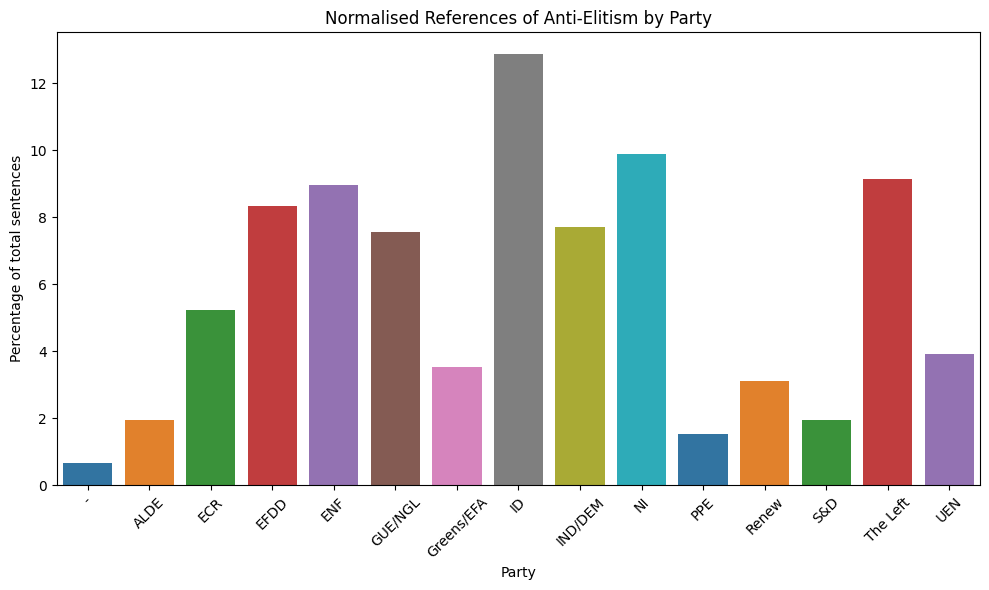

In [ ]:
# Visualise references of anti-elitism by party (normalised)

plt.figure(figsize=(10, 6))
sns.barplot(x=party_stats.index, y=party_stats['anti_elitism_normalised'], palette=line_palette)
plt.title('Normalised References of Anti-Elitism by Party')
plt.xlabel('Party')
plt.ylabel('Percentage of total sentences')
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig('../outputs/normalised_anti_elitism_by_party.png', dpi=150, bbox_inches='tight')
plt.show()

#### People-centrism

/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_70323/3374624608.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=party_stats.index, y=party_stats['people_centrism_normalised'], palette=line_palette)


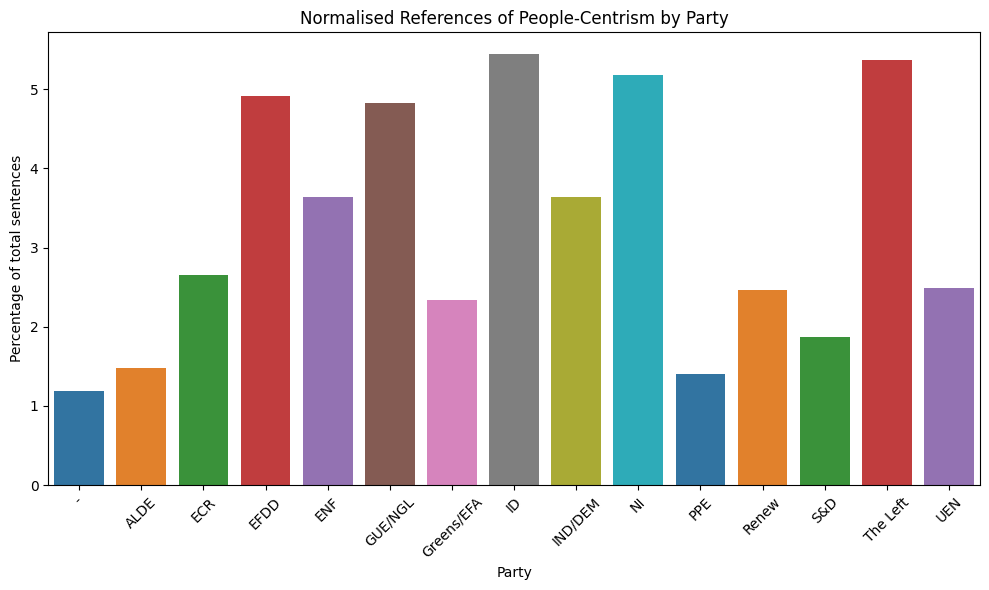

In [ ]:
# Visualise references of people-centrism by party (normalised)

plt.figure(figsize=(10, 6))
sns.barplot(x=party_stats.index, y=party_stats['people_centrism_normalised'], palette=line_palette)
plt.title('Normalised References of People-Centrism by Party')
plt.xlabel('Party')
plt.ylabel('Percentage of total sentences')
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig('../outputs/normalised_people_centrism_by_party.png', dpi=150, bbox_inches='tight')
plt.show()

#### Populism

/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_70323/674806753.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=party_stats.index, y=party_stats['populism_normalised'], palette=line_palette)


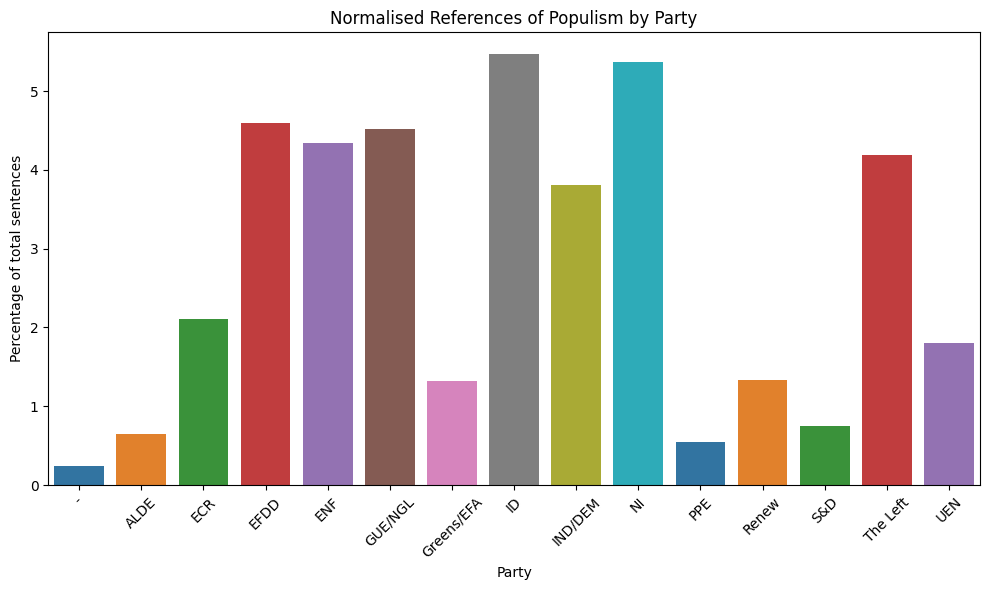

In [ ]:
# Visualise references of people-centrism by party (normalised)

plt.figure(figsize=(10, 6))
sns.barplot(x=party_stats.index, y=party_stats['populism_normalised'], palette=line_palette)
plt.title('Normalised References of Populism by Party')
plt.xlabel('Party')
plt.ylabel('Percentage of total sentences')
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig('../outputs/normalised_populism_by_party.png', dpi=150, bbox_inches='tight')
plt.show()

#### Populism combined

/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_70323/3342484288.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=party_stats.index, y=party_stats['populism_combined_normalised'], palette=line_palette)


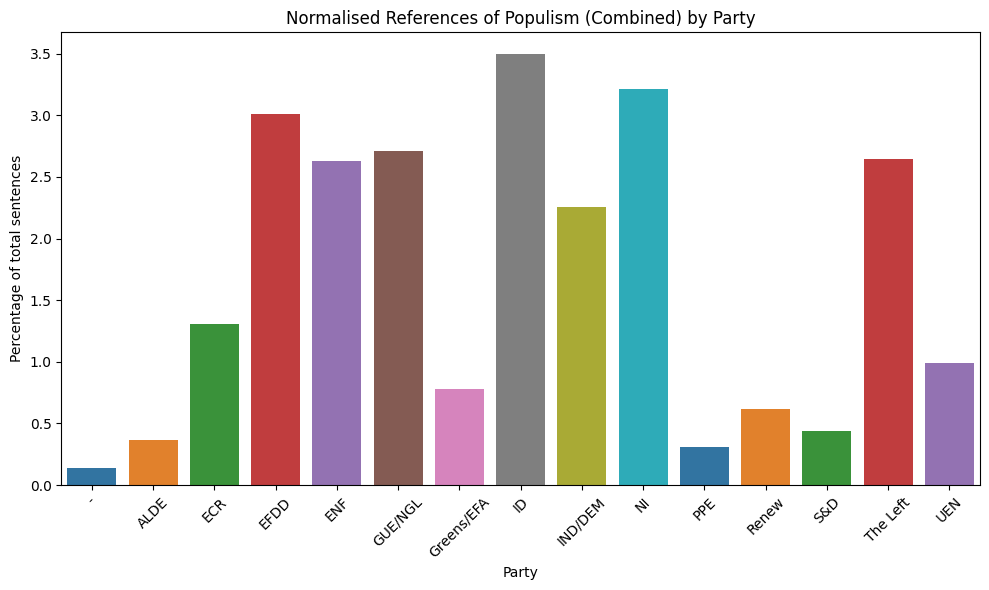

In [36]:
# Visualise references of people-centrism by party (normalised)

plt.figure(figsize=(10, 6))
sns.barplot(x=party_stats.index, y=party_stats['populism_combined_normalised'], palette=line_palette)
plt.title('Normalised References of Populism (Combined) by Party')
plt.xlabel('Party')
plt.ylabel('Percentage of total sentences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/normalised_populism_combined_by_party.png', dpi=150, bbox_inches='tight')
plt.show()

### **Dimensions of Populism over Time**

In [58]:
dimensions = [
    ('anti_elitism_binary', 'Anti-Elitism', 'steelblue'),
    ('people_centrism_binary', 'People-Centrism', 'darkorange'),
    ('populism_binary', 'Populism', 'green'),
    ('populism_combined', 'Combined Populism', 'red')
]

#### Normalised Plots

In [60]:
# Total sentences per year for normalisation
year_totals = ep.groupby('year')['sentence'].count().reset_index()
year_totals.columns = ['year', 'total_sentences']

In [61]:
# Sum per year and normalise
dim_cols = [d[0] for d in dimensions]
over_time = ep.groupby('year')[dim_cols].sum().reset_index()
over_time = over_time.merge(year_totals, on='year')
for dim in dim_cols:
    over_time[dim] = (over_time[dim] / over_time['total_sentences']) * 100

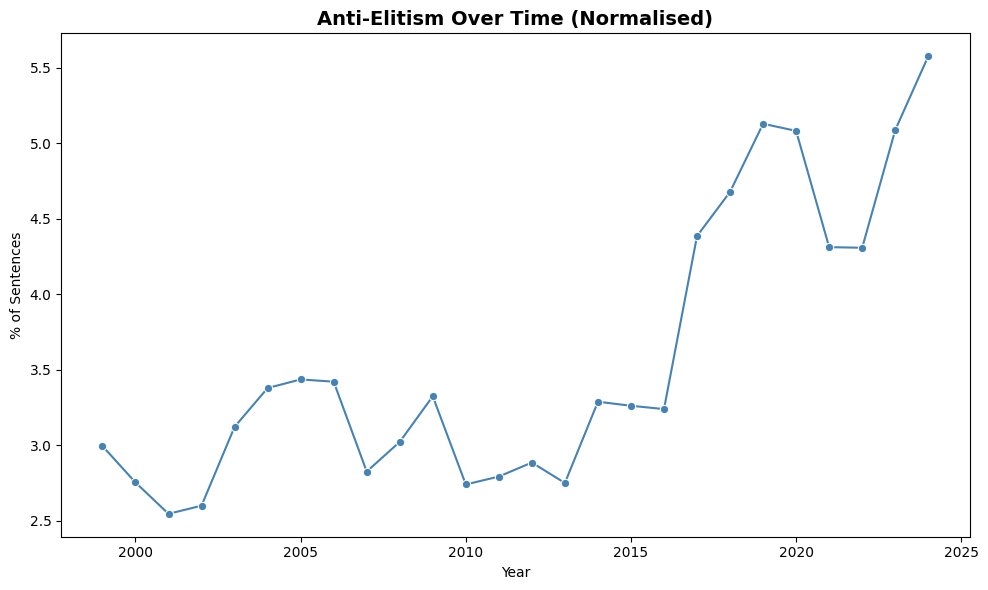

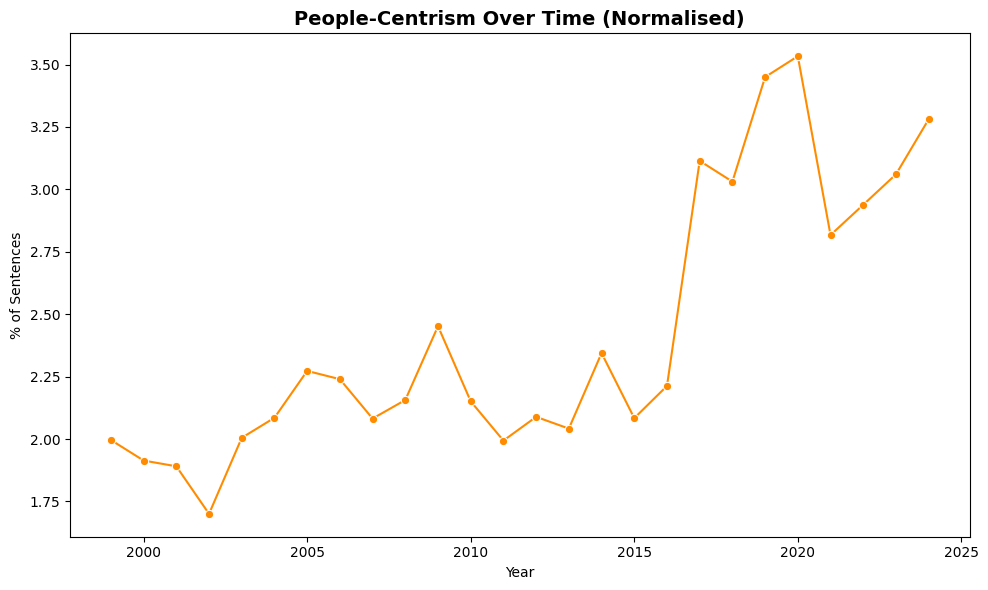

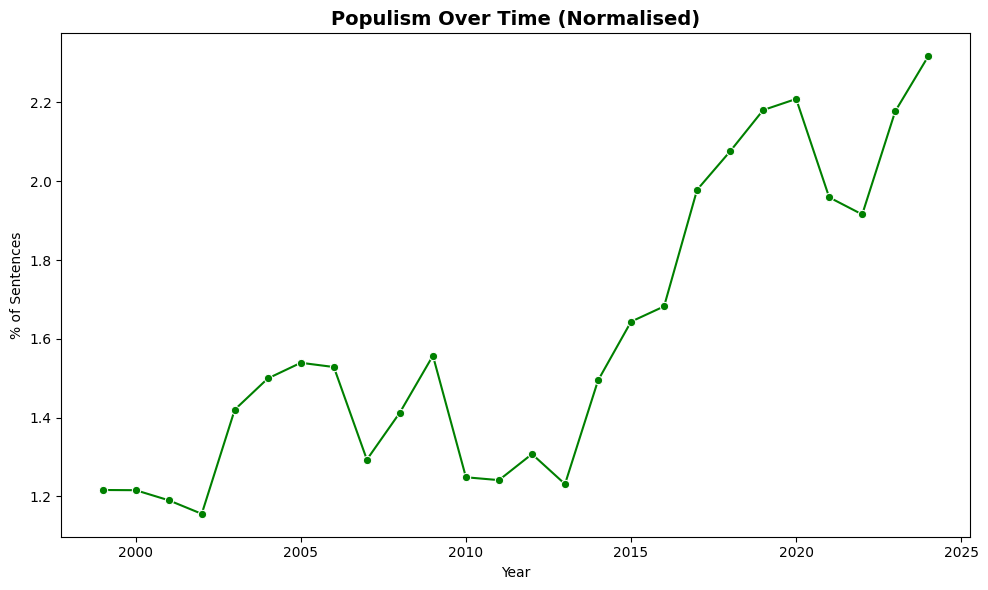

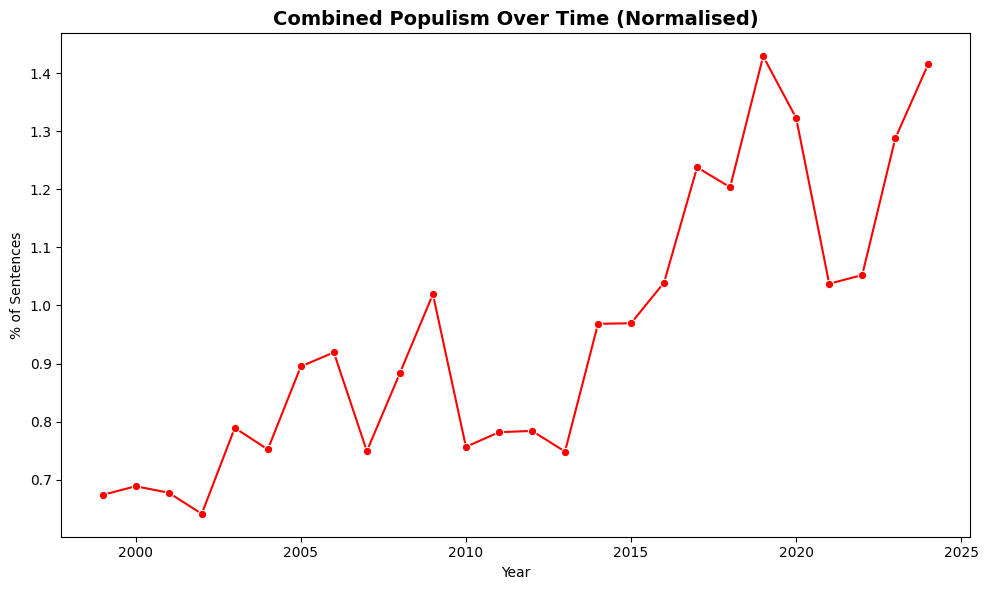

In [51]:
# Plot each dimension separately
for dim, title, color in dimensions:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(data=over_time, x='year', y=dim, marker='o', color=color, ax=ax)
    ax.set_title(f'{title} Over Time (Normalised)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('% of Sentences')
    plt.tight_layout()
    plt.savefig(f'../outputs/graphs/{title.lower().replace(" ", "_")}_over_time.png', dpi=150, bbox_inches='tight')
    plt.show()

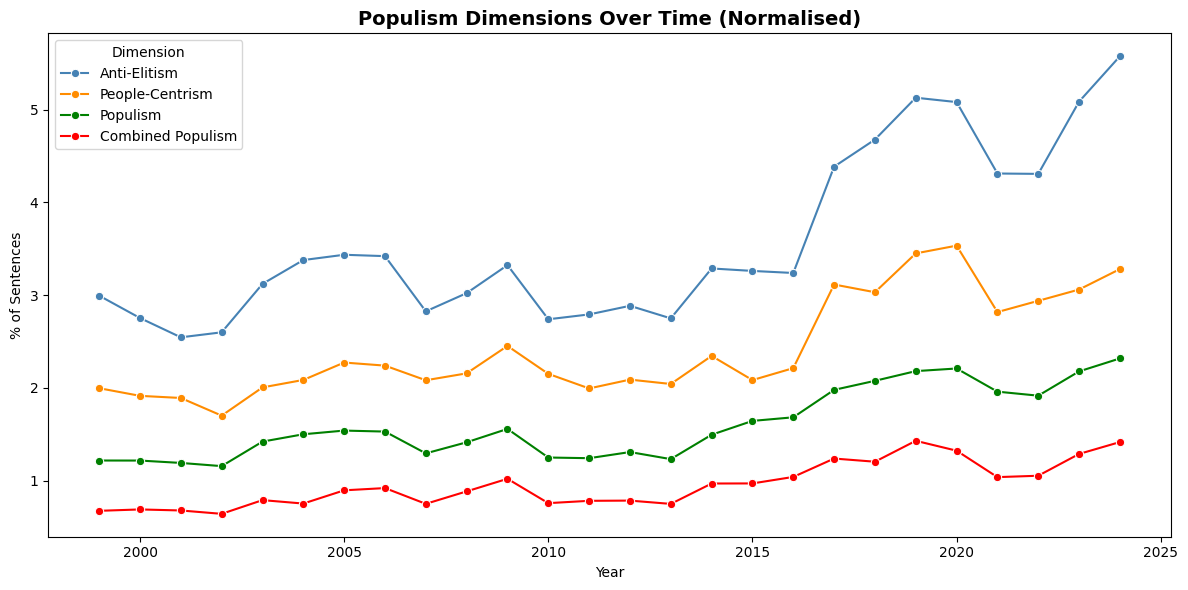

In [52]:
# Combined plot
fig, ax = plt.subplots(figsize=(12, 6))
for dim, title, color in dimensions:
    sns.lineplot(data=over_time, x='year', y=dim, marker='o', label=title, color=color, ax=ax)
ax.set_title('Populism Dimensions Over Time (Normalised)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% of Sentences')
ax.legend(title='Dimension')
plt.tight_layout()
plt.savefig('../outputs/graphs/combined_dimensions_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

#### All dimensions combined (not normalised)

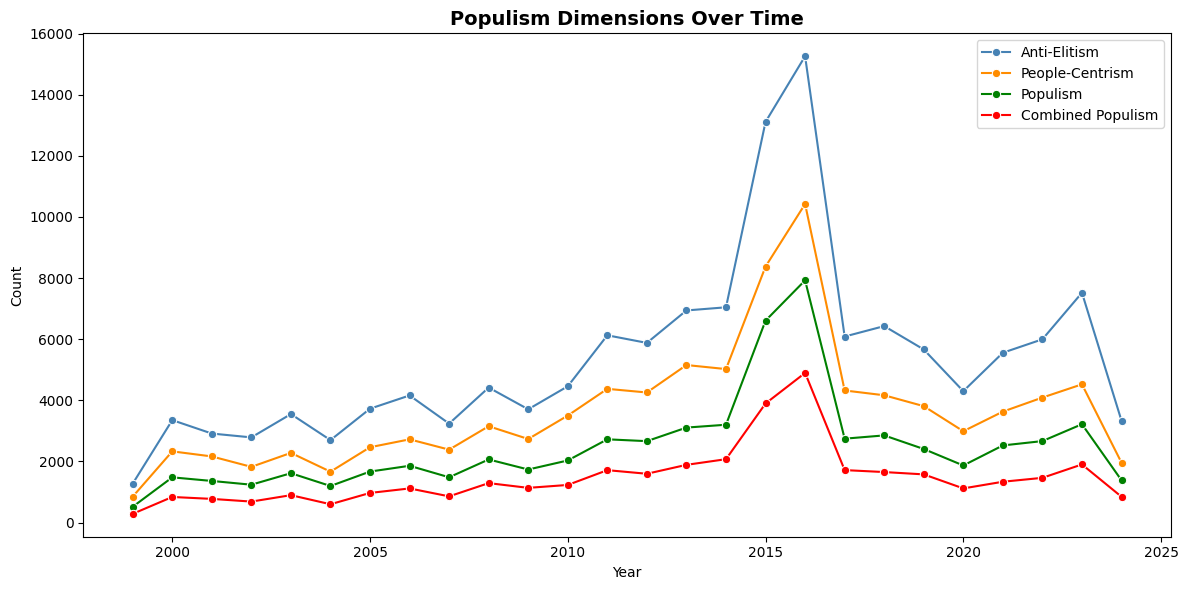

In [55]:
fig, ax = plt.subplots(figsize=(12, 6))

for dim, title, color in dimensions:
    over_time = ep.groupby('year')[dim].sum().reset_index()
    sns.lineplot(data=over_time, x='year', y=dim, marker='o', label=title, color=color, ax=ax)

ax.set_title('Populism Dimensions Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
#plt.savefig('../outputs/graphs/combined_dimensions_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

#### Add Election Years

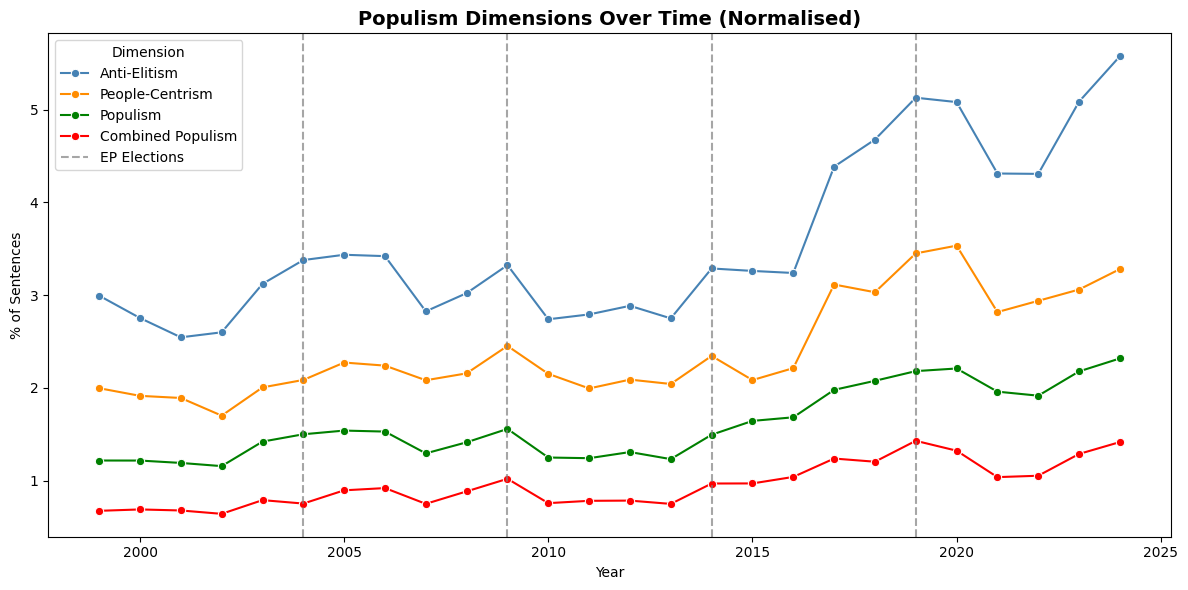

In [66]:
# Combined plot
fig, ax = plt.subplots(figsize=(12, 6))
for dim, title, color in dimensions:
    sns.lineplot(data=over_time, x='year', y=dim, marker='o', label=title, color=color, ax=ax)

election_years = [2004, 2009, 2014, 2019]
for year in election_years:
    ax.axvline(x=year, color='grey', linestyle='--', alpha=0.7, label='EP Elections ' if year == election_years[0] else '')

ax.set_title('Populism Dimensions Over Time (Normalised)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% of Sentences')
ax.legend(title='Dimension')
plt.tight_layout()
plt.savefig('../outputs/graphs/combined_dimensions_over_time_elections.png', dpi=150, bbox_inches='tight')
plt.show()

## **Indiviudal Metrics**

### Top populist speakers 

In [69]:
top20_populism = ep.groupby(['speaker', 'party'])['populism_combined'].sum().sort_values(ascending=False).head(20)
print(top20_populism)

speaker                          party  
João Ferreira                    GUE/NGL    704
Κωνσταντίνος Παπαδάκης           NI         429
Jean-Luc Mélenchon               GUE/NGL    425
Σωτήριος Ζαριανόπουλος           NI         396
Ilda Figueiredo                  GUE/NGL    343
Georgios Toussas                 GUE/NGL    309
Inês Cristina Zuber              GUE/NGL    300
Bruno Gollnisch                  NI         296
Νότης Μαριάς                     ECR        255
Miguel Viegas                    GUE/NGL    254
Athanasios Pafilis               GUE/NGL    222
Armonia Bordes                   GUE/NGL    215
Λάμπρος Φουντούλης               NI         205
Ελευθέριος Συναδινός             NI         191
Ангел Джамбазки                  ECR        185
Efstratios Korakas               GUE/NGL    182
Andreas Mölzer                   NI         177
Nigel Farage                     EFDD       175
William (The Earl of) Dartmouth  EFDD       174
Gerard Batten                    EFDD       174

In [70]:
top20_elite = ep.groupby(['speaker', 'party'])['anti_elitism_binary'].sum().sort_values(ascending=False).head(20)
print(top20_elite)

speaker                  party     
João Ferreira            GUE/NGL       2020
Jean-Luc Mélenchon       GUE/NGL       1476
Bruno Gollnisch          NI            1150
Ilda Figueiredo          GUE/NGL        885
Inês Cristina Zuber      GUE/NGL        810
Ангел Джамбазки          ECR            795
Νότης Μαριάς             ECR            760
Nigel Farage             EFDD           740
Miguel Viegas            GUE/NGL        720
Σωτήριος Ζαριανόπουλος   NI             678
Κωνσταντίνος Παπαδάκης   NI             674
Daniel Hannan            ECR            645
Philippe Lamberts        Greens/EFA     625
Andreas Mölzer           NI             607
Mick Wallace             The Left       599
Clare Daly               The Left       567
Marie-Christine Vergiat  GUE/NGL        544
Dominique Bilde          ENF            540
Ελευθέριος Συναδινός     NI             493
Athanasios Pafilis       GUE/NGL        488
Name: anti_elitism_binary, dtype: int64


In [71]:
top20_people = ep.groupby(['speaker', 'party'])['people_centrism_binary'].sum().sort_values(ascending=False).head(20)
print(top20_people)

speaker                 party     
João Ferreira           GUE/NGL       1098
Ilda Figueiredo         GUE/NGL        641
Κωνσταντίνος Παπαδάκης  NI             598
Σωτήριος Ζαριανόπουλος  NI             564
Jean-Luc Mélenchon      GUE/NGL        548
Inês Cristina Zuber     GUE/NGL        508
Νότης Μαριάς            ECR            468
Georgios Toussas        GUE/NGL        425
Bruno Gollnisch         NI             414
Miguel Viegas           GUE/NGL        389
Armonia Bordes          GUE/NGL        358
Jonathan Arnott         EFDD           336
Philippe Lamberts       Greens/EFA     335
Andreas Mölzer          NI             330
Ангел Джамбазки         ECR            321
Athanasios Pafilis      GUE/NGL        312
Paul Murphy             GUE/NGL        303
Λάμπρος Φουντούλης      NI             293
Ελευθέριος Συναδινός    NI             287
Ruža Tomašić            ECR            282
Name: people_centrism_binary, dtype: int64


In [74]:
speaker_stats = ep.groupby(['speaker', 'party']).agg(
    populism_count=('populism_combined', 'sum'),
    total_sentences=('sentence', 'count')
)
speaker_stats['normalised'] = (speaker_stats['populism_count'] / speaker_stats['total_sentences']) * 100
top20 = speaker_stats[speaker_stats['total_sentences'] >= 50].sort_values('normalised', ascending=False).head(20)
top20.head(20)

,,populism_count,total_sentences,normalised
speaker,party,,,
Γεώργιος Τούσσας,GUE/NGL,76,299,25.418060
Charalampos Angourakis,GUE/NGL,157,733,21.418827
Georgios Toussas,GUE/NGL,309,1499,20.613742
Florian Philippot,EFDD,18,89,20.224719
Claire Fox,NI,43,213,20.187793
Χαράλαμπος Αγγουράκης,GUE/NGL,89,442,20.135747
Κωνσταντίνος Παπαδάκης,NI,429,2157,19.888734
Henrik Overgaard Nielsen,NI,10,51,19.607843
Σωτήριος Ζαριανόπουλος,NI,396,2188,18.098720


### Populist Dimensions per Party per Period 

In [76]:
# Total sentences per period-party
total_sentences_pp = ep.groupby(['period', 'party']).size().reset_index(name='total_sentences')

party_period = total_sentences_pp.copy()

# Add normalised share for each dimension
for dim_col, dim_name, *_ in dimensions:
    populist_sentences = ep.groupby(['period', 'party'])[dim_col].sum().reset_index(name=f'{dim_name}_count')
    party_period = pd.merge(party_period, populist_sentences, on=['period', 'party'])
    party_period[f'{dim_name}_share'] = (party_period[f'{dim_name}_count'] / party_period['total_sentences']) * 100

print(party_period)

    period       party  total_sentences  Anti-Elitism_count  \
0        5           -            40308                 156   
1        5        ALDE            46913                 866   
2        5     GUE/NGL            54033                3465   
3        5  Greens/EFA            51556                1492   
4        5     IND/DEM            20433                1130   
5        5          NI            17639                1240   
6        5         PPE           163629                3254   
7        5         S&D           129536                2534   
8        5         UEN            24372                1143   
9        6           -            43935                 231   
10       6        ALDE            62685                1583   
11       6     GUE/NGL            42377                3287   
12       6  Greens/EFA            35596                1274   
13       6     IND/DEM            30603                2796   
14       6          NI            26064                

/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_70323/1004670475.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Period')
/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_70323/1004670475.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Period')
/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_70323/1004670475.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Period')
/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_70323/1004670475.py:13: UserWarning: No artists with labels found to put in legend.  Note that art

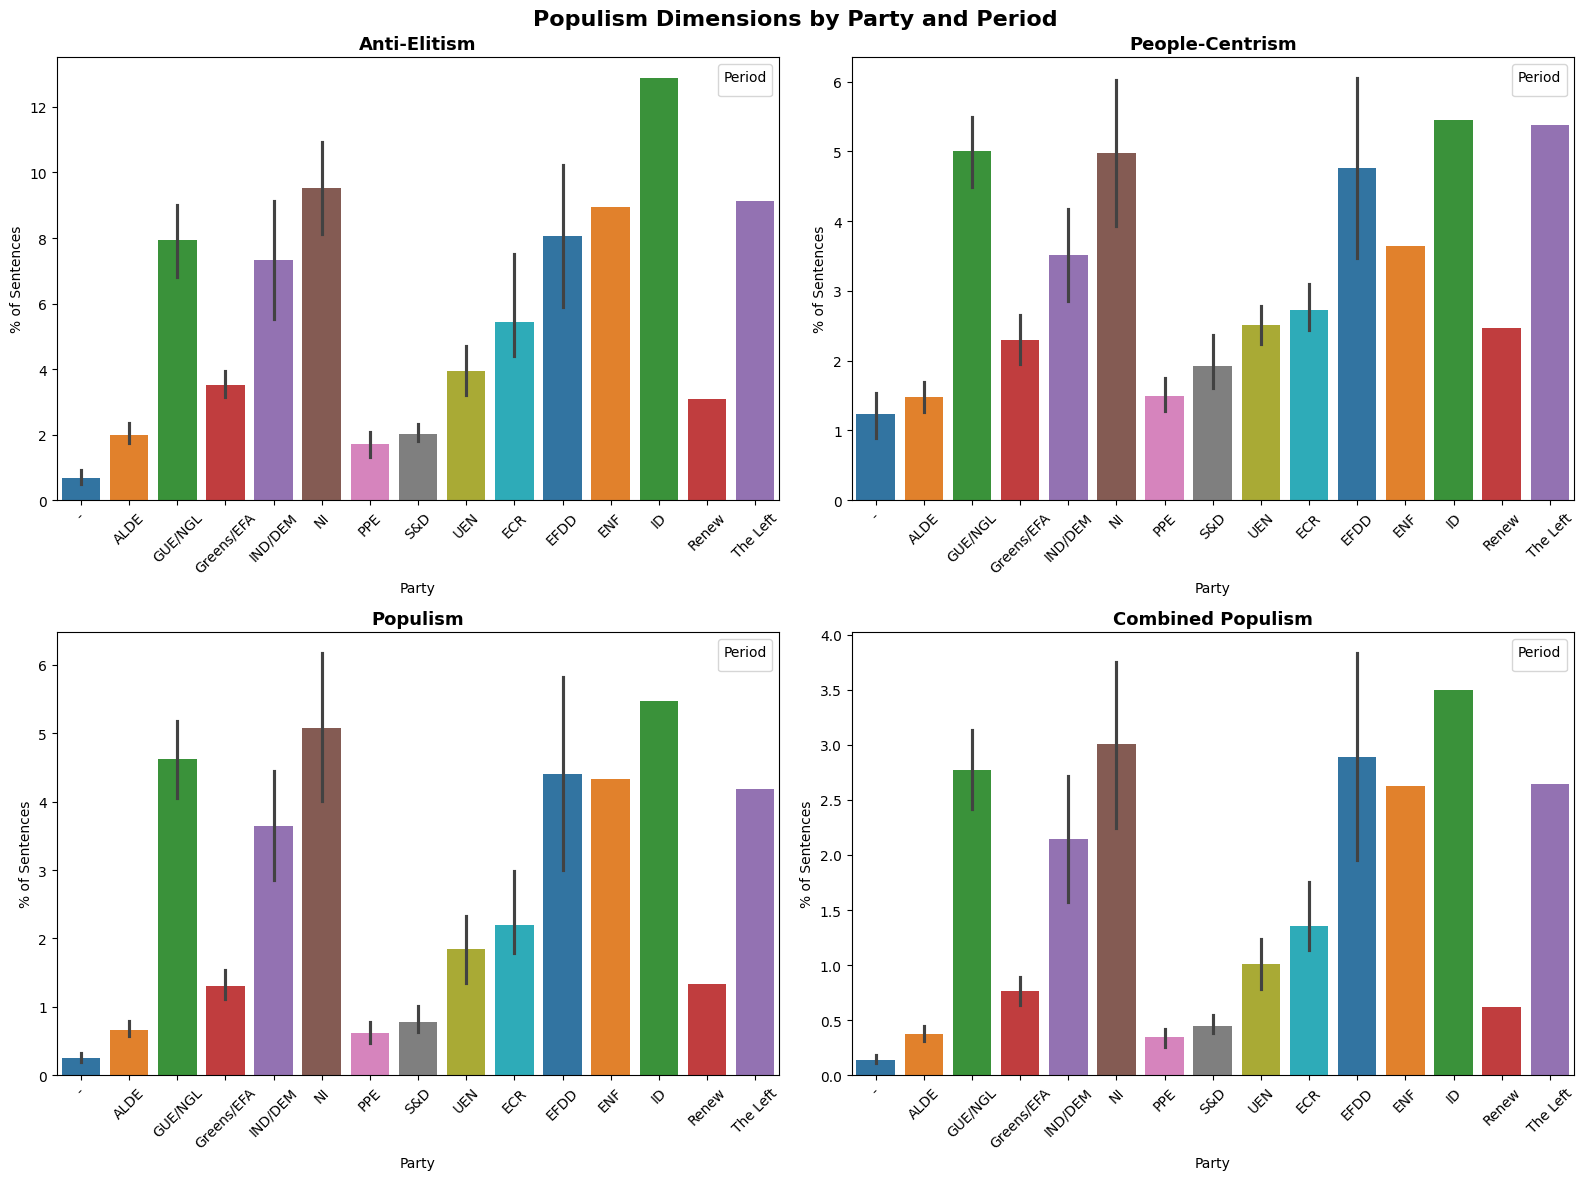

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for (dim_col, dim_name, *_), ax in zip(dimensions[:4], axes.flatten()):
    share_col = f'{dim_name}_share'
    
    sns.barplot(data=party_period, x='party', y=share_col, hue='party', 
                palette=line_palette, ax=ax)
    
    ax.set_title(dim_name.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_xlabel('Party')
    ax.set_ylabel('% of Sentences')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Period')

plt.suptitle('Populism Dimensions by Party and Period', fontsize=16, fontweight='bold')
plt.tight_layout()
#plt.savefig('../outputs/graphs/dimensions_party_period.png', dpi=150, bbox_inches='tight')
plt.show()

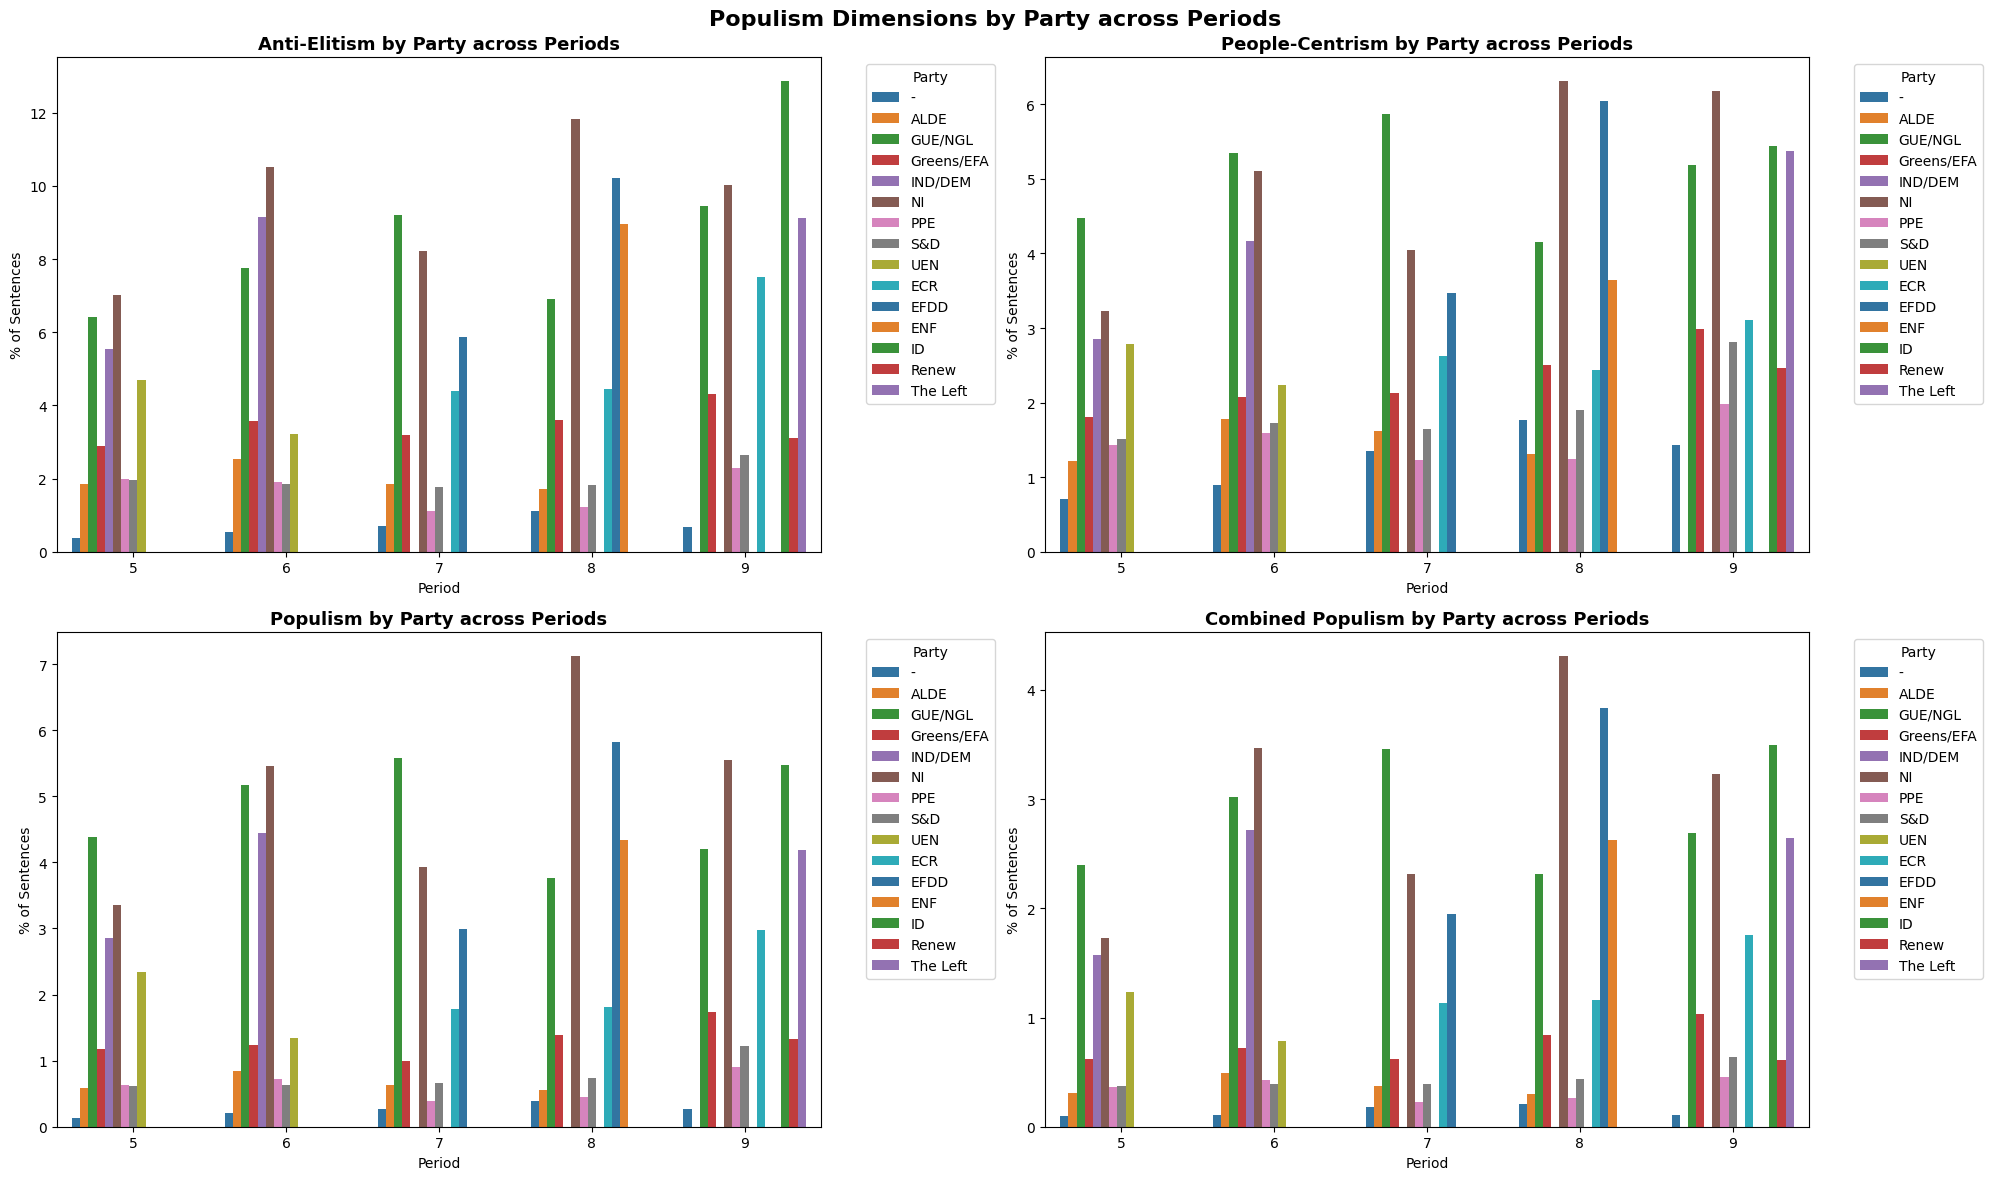

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

for (dim_col, dim_name, *_), ax in zip(dimensions[:4], axes.flatten()):
    share_col = f'{dim_name}_share'
    
    sns.barplot(
        data=party_period,
        x='period',
        y=share_col,
        hue='party',
        palette=line_palette,
        ax=ax
    )
    ax.set_title(f'{dim_name.replace("_", " ").title()} by Party across Periods', fontsize=13, fontweight='bold')
    ax.set_ylabel('% of Sentences')
    ax.set_xlabel('Period')
    ax.legend(title='Party', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Populism Dimensions by Party across Periods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/bar_charts/dimensions_party_period.png', dpi=300, bbox_inches='tight')
plt.show()

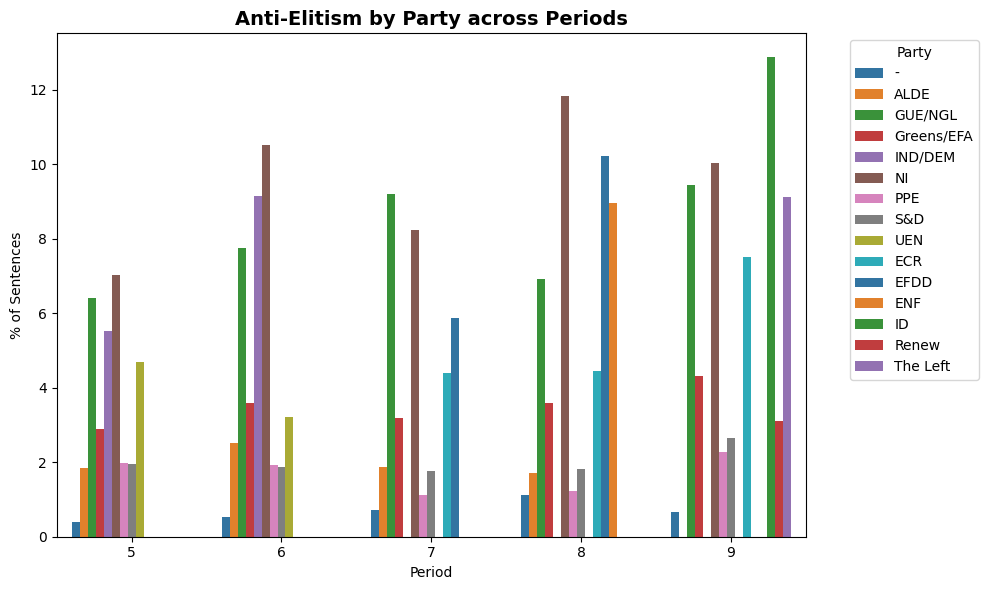

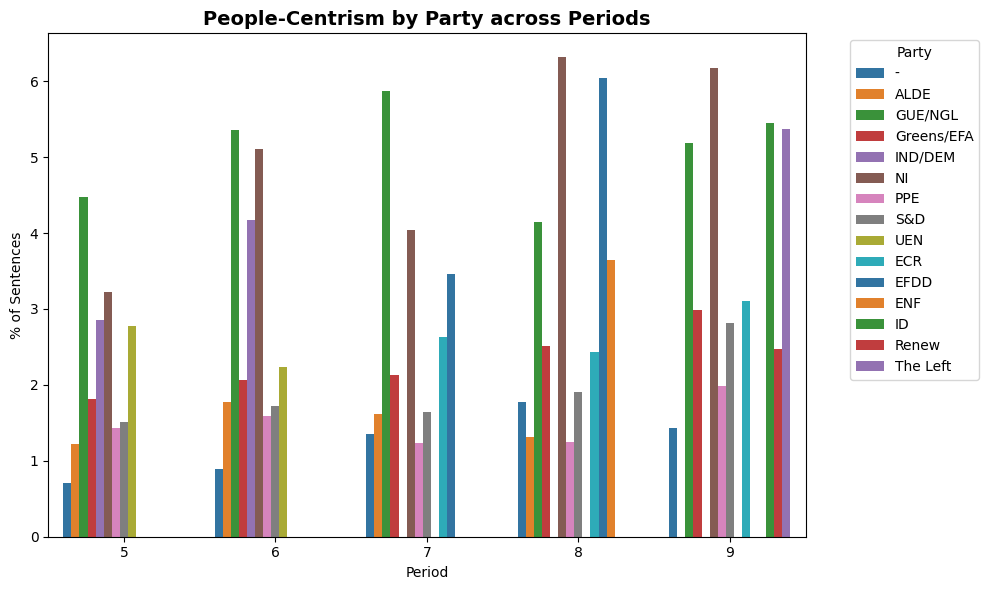

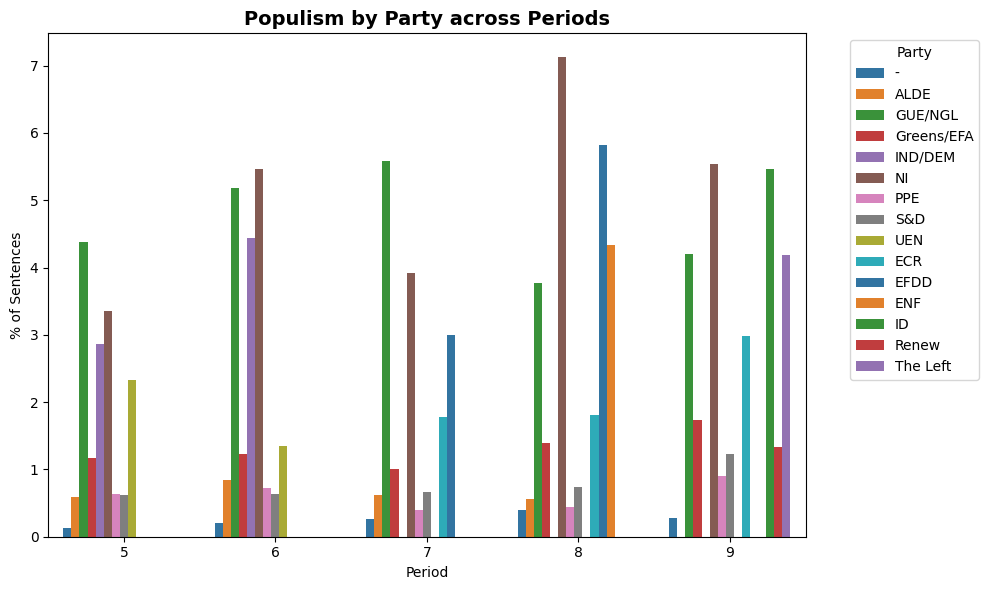

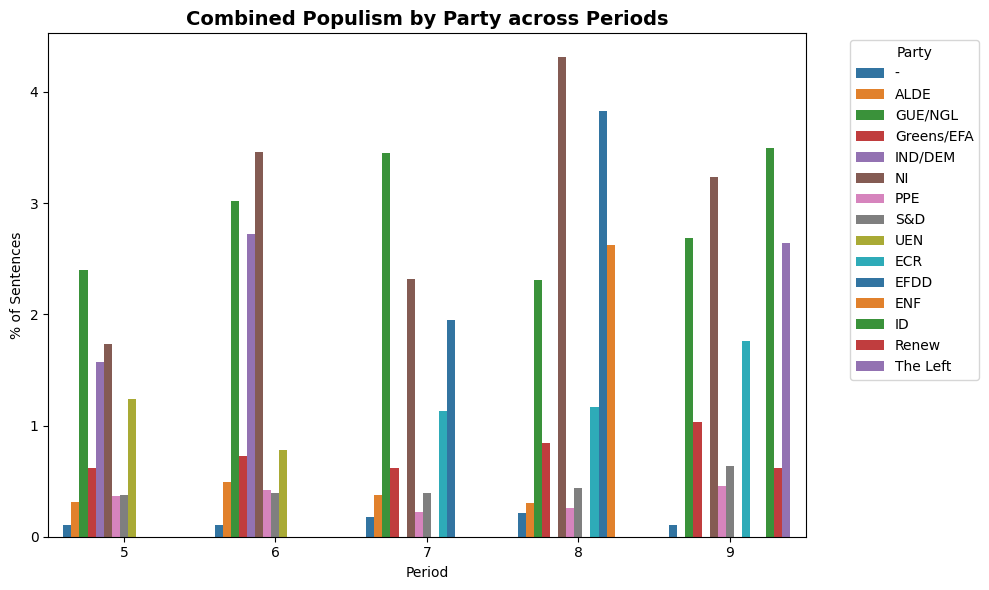

In [82]:
for dim_col, dim_name, *_ in dimensions[:4]:
    share_col = f'{dim_name}_share'
    
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=party_period,
        x='period',
        y=share_col,
        hue='party',
        palette=line_palette
    )
    plt.title(f'{dim_name.replace("_", " ").title()} by Party across Periods', fontsize=14, fontweight='bold')
    plt.ylabel('% of Sentences')
    plt.xlabel('Period')
    plt.legend(title='Party', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'../outputs/bar_charts/{dim_name}_party_period.png', dpi=300, bbox_inches='tight')
    plt.show()